In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install catboost
!pip install xgboost
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


In [5]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, confusion_matrix,
    precision_recall_curve, auc, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
os.makedirs("results", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device : {DEVICE}")

Device : cpu


In [6]:
train_df = pd.read_csv("/content/drive/MyDrive/preprocessed_datasets/train_preprocessed.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/preprocessed_datasets/test_preprocessed.csv")

FEAT_COLS = [c for c in train_df.columns if c != "label"]

X_train = train_df[FEAT_COLS].values.astype(np.float32)
y_train = train_df["label"].values.astype(np.int64)
X_test  = test_df[FEAT_COLS].values.astype(np.float32)
y_test  = test_df["label"].values.astype(np.int64)

print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"Train label dist — Normal: {(y_train==0).sum():,}  Attack: {(y_train==1).sum():,}")
print(f"Test  label dist — Normal: {(y_test==0).sum():,}  Attack: {(y_test==1).sum():,}")

X_train : (97788, 41)  y_train : (97788,)
X_test  : (82332, 41)   y_test  : (82332,)
Train label dist — Normal: 48,894  Attack: 48,894
Test  label dist — Normal: 37,000  Attack: 45,332


In [7]:
train_df

,dur,proto,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,...,state_RST,service_-,service_dns,service_ftp,service_ftp-data,service_http,service_pop3,service_smtp,service_ssh,label
0,-0.3560,0.0000,-0.2500,-0.3333,-0.3381,-0.1698,0.0059,-0.0303,-0.0062,-0.4000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
1,0.1682,0.0000,0.2500,1.5556,-0.1389,2.3577,0.0076,-0.0403,0.7749,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
2,1.1336,0.0000,-0.1250,0.3333,-0.2937,2.3577,-0.0176,-0.0522,0.0765,-0.2000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
3,1.1917,0.0000,0.1250,0.1111,-0.1833,0.0017,-0.0178,-0.0502,-0.0143,-0.2000,...,0.0000,-1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
4,-0.0306,0.0000,0.0000,-0.2222,-0.2226,-0.1423,-0.0101,-0.0401,-0.0134,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97783,-0.1067,0.0000,0.0000,-0.2222,-0.0746,-0.1423,-0.0074,-0.0250,-0.0121,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1
97784,0.0948,0.0000,0.0000,-0.1111,-0.1132,0.1242,-0.0116,-0.0376,0.0035,0.0000,...,0.0000,-1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1
97785,1.9371,0.0000,1.6258,2.2778,0.2463,2.3577,0.0032,-0.0460,0.7463,1.0000,...,0.0000,-1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1
97786,1.5375,0.0000,0.0000,-0.1111,-0.2109,-0.1176,-0.0199,-0.0515,-0.0177,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1


In [8]:

RESULTS = {}

def compute_metrics(name, y_true, y_pred, y_prob, split):
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    f1m   = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f2    = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    f2m   = fbeta_score(y_true, y_pred, beta=2, average="macro", zero_division=0)
    cm    = confusion_matrix(y_true, y_pred)
    if y_prob is not None:
        p_curve, r_curve, _ = precision_recall_curve(y_true, y_prob)
        auc_pr = auc(r_curve, p_curve)
    else:
        auc_pr = float("nan")
    return {
        "split":    split,
        "accuracy": acc,
        "precision": prec,
        "recall":   rec,
        "f1":       f1,
        "f1_macro": f1m,
        "f2":       f2,
        "f2_macro": f2m,
        "auc_pr":   auc_pr,
        "cm":       cm,
    }

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, has_proba=True):
    if has_proba:
        prob_tr = model.predict_proba(X_tr)[:, 1]
        prob_te = model.predict_proba(X_te)[:, 1]
    else:
        prob_tr = None
        prob_te = None

    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    m_tr = compute_metrics(name, y_tr, pred_tr, prob_tr, "train")
    m_te = compute_metrics(name, y_te, pred_te, prob_te, "test")

    RESULTS[name] = {"train": m_tr, "test": m_te}

    print(f"\n{'='*58}")
    print(f"  {name}")
    print(f"{'='*58}")
    header = f"  {'Metric':<18} {'Train':>10} {'Test':>10}"
    print(header)
    print(f"  {'-'*38}")
    for key in ["accuracy","precision","recall","f1","f1_macro","f2","f2_macro","auc_pr"]:
        tr_val = m_tr[key]
        te_val = m_te[key]
        print(f"  {key:<18} {tr_val:>10.4f} {te_val:>10.4f}")

In [9]:
print("Training Logistic Regression...")
t0 = time.time()
lr = LogisticRegression(max_iter=1000, solver="lbfgs", C=1.0,
                         class_weight="balanced", random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
evaluate_model("Logistic Regression", lr, X_train, y_train, X_test, y_test)

Training Logistic Regression...
Done in 20.5s

  Logistic Regression
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.8759     0.7919
  precision              0.8308     0.7394
  recall                 0.9440     0.9606
  f1                     0.8838     0.8356
  f1_macro               0.8753     0.7761
  f2                     0.9190     0.9064
  f2_macro               0.8747     0.7689
  auc_pr                 0.8853     0.8659


In [10]:
print("Training Naive Bayes...")
t0 = time.time()
nb = GaussianNB()
nb.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
evaluate_model("Naive Bayes", nb, X_train, y_train, X_test, y_test)

Training Naive Bayes...
Done in 0.0s

  Naive Bayes
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.7996     0.5307
  precision              0.7402     0.5752
  recall                 0.9234     0.5646
  f1                     0.8217     0.5698
  f1_macro               0.7965     0.5267
  f2                     0.8799     0.5667
  f2_macro               0.7955     0.5268
  auc_pr                 0.8231     0.5503


In [11]:
print("Training KNN (k=7)...")
t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=7, algorithm="ball_tree", metric="minkowski", n_jobs=-1)
knn.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
evaluate_model("KNN", knn, X_train, y_train, X_test, y_test, has_proba=False)

Training KNN (k=7)...
Done in 0.4s

  KNN
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.9276     0.8572
  precision              0.9043     0.8111
  recall                 0.9563     0.9656
  f1                     0.9296     0.8816
  f1_macro               0.9275     0.8509
  f2                     0.9454     0.9301
  f2_macro               0.9274     0.8451
  auc_pr                    nan        nan


In [12]:
print("Training SVM (Linear)...")
t0 = time.time()
svm = SVC(kernel="linear", C=0.1, class_weight="balanced", random_state=42, probability=True, max_iter=2000)
svm.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
evaluate_model("SVM", svm, X_train, y_train, X_test, y_test, has_proba=False)

Training SVM (Linear)...
Done in 234.4s

  SVM
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.5519     0.3166
  precision              0.5317     0.3681
  recall                 0.8715     0.3363
  f1                     0.6605     0.3515
  f1_macro               0.5010     0.3147
  f2                     0.7727     0.3422
  f2_macro               0.5196     0.3143
  auc_pr                    nan        nan


In [13]:
print("Training Decision Tree...")
t0 = time.time()
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10,
                              class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
evaluate_model("Decision Tree", dt, X_train, y_train, X_test, y_test)

Training Decision Tree...
Done in 2.5s

  Decision Tree
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.9163     0.8406
  precision              0.8759     0.7853
  recall                 0.9700     0.9779
  f1                     0.9206     0.8711
  f1_macro               0.9161     0.8312
  f2                     0.9496     0.9322
  f2_macro               0.9156     0.8238
  auc_pr                 0.9743     0.9802


In [14]:
print("Training Random Forest...")
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                              min_samples_leaf=5, class_weight="balanced",
                              random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)

Training Random Forest...
Done in 35.4s

  Random Forest
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.9619     0.8443
  precision              0.9352     0.7872
  recall                 0.9926     0.9831
  f1                     0.9631     0.8743
  f1_macro               0.9619     0.8350
  f2                     0.9806     0.9365
  f2_macro               0.9617     0.8273
  auc_pr                 0.9957     0.9821


In [15]:
print("Training Gradient Boosting...")
t0 = time.time()
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                  max_depth=5, subsample=0.8,
                                  random_state=42)
gb.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
evaluate_model("Gradient Boosting", gb, X_train, y_train, X_test, y_test)

Training Gradient Boosting...
Done in 182.6s

  Gradient Boosting
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.9326     0.8551
  precision              0.9019     0.8023
  recall                 0.9708     0.9778
  f1                     0.9351     0.8814
  f1_macro               0.9325     0.8476
  f2                     0.9562     0.9368
  f2_macro               0.9322     0.8407
  auc_pr                 0.9851     0.9843


In [16]:
print("Training XGBoost...")
t0 = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1,
                              max_depth=5, subsample=0.8,
                              colsample_bytree=0.8, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
evaluate_model("XGBoost", xgb_model, X_train, y_train, X_test, y_test)

Training XGBoost...
Done in 2.3s

  XGBoost
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.9287     0.8494
  precision              0.8955     0.7939
  recall                 0.9707     0.9811
  f1                     0.9316     0.8776
  f1_macro               0.9286     0.8409
  f2                     0.9547     0.9369
  f2_macro               0.9283     0.8335
  auc_pr                 0.9837     0.9849


In [17]:
print("Training LightGBM...")
t0 = time.time()
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1,
                               max_depth=5, subsample=0.8,
                               colsample_bytree=0.8, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                               random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
evaluate_model("LightGBM", lgb_model, X_train, y_train, X_test, y_test)

Training LightGBM...
Done in 2.0s

  LightGBM
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.9271     0.8489
  precision              0.8927     0.7930
  recall                 0.9709     0.9818
  f1                     0.9301     0.8774
  f1_macro               0.9269     0.8403
  f2                     0.9541     0.9372
  f2_macro               0.9266     0.8328
  auc_pr                 0.9836     0.9852


In [18]:
print("Training CatBoost...")
t0 = time.time()
cb_model = CatBoostClassifier(iterations=200, learning_rate=0.1,
                              depth=5, subsample=0.8,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              random_state=42, verbose=0, thread_count=-1)
cb_model.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
evaluate_model("CatBoost", cb_model, X_train, y_train, X_test, y_test)

Training CatBoost...
Done in 4.7s

  CatBoost
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.9201     0.8424
  precision              0.8814     0.7851
  recall                 0.9708     0.9826
  f1                     0.9240     0.8728
  f1_macro               0.9199     0.8328
  f2                     0.9515     0.9356
  f2_macro               0.9194     0.8251
  auc_pr                 0.9788     0.9839


In [19]:
class NIDSNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [20]:

EPOCHS      = 30
BATCH_SIZE  = 512
LR          = 1e-3
WEIGHT_DECAY= 1e-4

pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32,
    device=DEVICE
)

X_tr_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)
X_te_t = torch.tensor(X_test,  dtype=torch.float32, device=DEVICE)
y_te_t = torch.tensor(y_test,  dtype=torch.float32, device=DEVICE)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True
)

dnn   = NIDSNet(in_features=X_train.shape[1]).to(DEVICE)
crit  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optim_= optim.AdamW(dnn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = optim.lr_scheduler.CosineAnnealingLR(optim_, T_max=EPOCHS)

history = {
    "train_loss": [], "train_acc": [],
    "test_loss":  [], "test_acc":  []
}

print(f"DNN training on device: {DEVICE}\n")
print(f"  {'Epoch':>6}  {'Tr Loss':>9}  {'Tr Acc':>8}  {'Te Loss':>9}  {'Te Acc':>8}  {'LR':>10}")
print(f"  {'-'*62}")

for epoch in tqdm(range(1, EPOCHS + 1), desc="DNN Epochs", ncols=80):
    dnn.train()
    running_loss = 0.0
    running_correct = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optim_.zero_grad()
        logits = dnn(xb)
        loss   = crit(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(dnn.parameters(), 1.0)
        optim_.step()
        running_loss    += loss.item() * xb.size(0)
        running_correct += ((torch.sigmoid(logits) >= 0.5).long() == yb.long()).sum().item()

    sched.step()

    tr_loss = running_loss / len(X_train)
    tr_acc  = running_correct / len(X_train)

    dnn.eval()
    with torch.no_grad():
        te_logits = dnn(X_te_t.to(DEVICE))
        te_loss   = crit(te_logits, y_te_t.to(DEVICE)).item()
        te_acc    = ((torch.sigmoid(te_logits) >= 0.5).long() == y_te_t.to(DEVICE).long()).float().mean().item()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    if epoch % 5 == 0 or epoch == 1:
        cur_lr = optim_.param_groups[0]["lr"]
        print(f"  {epoch:>6}  {tr_loss:>9.4f}  {tr_acc:>8.4f}  {te_loss:>9.4f}  {te_acc:>8.4f}  {cur_lr:>10.2e}")

print(f"\nFinal — Train Loss: {history['train_loss'][-1]:.4f}  Train Acc: {history['train_acc'][-1]:.4f}")
print(f"         Test  Loss: {history['test_loss'][-1]:.4f}  Test  Acc: {history['test_acc'][-1]:.4f}")

DNN training on device: cpu

   Epoch    Tr Loss    Tr Acc    Te Loss    Te Acc          LR
  --------------------------------------------------------------


DNN Epochs:   3%|█                               | 1/30 [00:03<01:48,  3.74s/it]

       1     0.3727    0.8426     0.4401    0.8013    9.97e-04


DNN Epochs:  17%|█████▎                          | 5/30 [00:16<01:21,  3.26s/it]

       5     0.2384    0.8972     0.3759    0.8058    9.33e-04


...

      20     0.2053    0.9026     0.3056    0.8176    2.50e-04


DNN Epochs:  83%|█████████████████████████▊     | 25/30 [01:17<00:16,  3.26s/it]

      25     0.2006    0.9037     0.2993    0.8204    6.70e-05


DNN Epochs: 100%|███████████████████████████████| 30/30 [01:32<00:00,  3.08s/it]

      30     0.1988    0.9041     0.3017    0.8202    0.00e+00

Final — Train Loss: 0.1988  Train Acc: 0.9041
         Test  Loss: 0.3017  Test  Acc: 0.8202


In [21]:

dnn.eval()
with torch.no_grad():
    tr_logits = dnn(X_tr_t.to(DEVICE))
    te_logits = dnn(X_te_t.to(DEVICE))
    tr_probs  = torch.sigmoid(tr_logits).cpu().numpy()
    te_probs  = torch.sigmoid(te_logits).cpu().numpy()

tr_preds = (tr_probs >= 0.5).astype(int)
te_preds = (te_probs >= 0.5).astype(int)

m_tr = compute_metrics("DNN", y_train, tr_preds, tr_probs, "train")
m_te = compute_metrics("DNN", y_test,  te_preds, te_probs, "test")
RESULTS["DNN"] = {"train": m_tr, "test": m_te}

print(f"\n{'='*58}")
print("  Deep Neural Network")
print(f"{'='*58}")
print(f"  {'Metric':<18} {'Train':>10} {'Test':>10}")
print(f"  {'-'*38}")
for key in ["accuracy","precision","recall","f1","f1_macro","f2","f2_macro","auc_pr"]:
    print(f"  {key:<18} {m_tr[key]:>10.4f} {m_te[key]:>10.4f}")


  Deep Neural Network
  Metric                  Train       Test
  --------------------------------------
  accuracy               0.9059     0.8202
  precision              0.8521     0.7573
  recall                 0.9825     0.9912
  f1                     0.9126     0.8586
  f1_macro               0.9054     0.8059
  f2                     0.9533     0.9335
  f2_macro               0.9044     0.7971
  auc_pr                 0.9689     0.9729


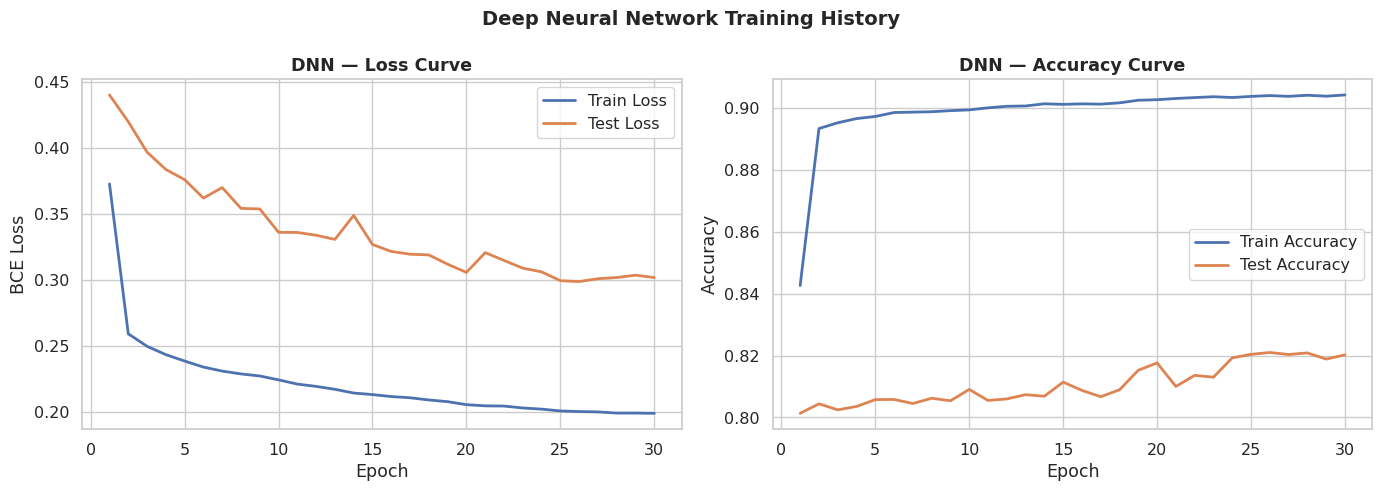

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color="#4C72B0", linewidth=2)
axes[0].plot(epochs_range, history["test_loss"],  label="Test Loss",  color="#DD8452", linewidth=2)
axes[0].set_title("DNN — Loss Curve", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Accuracy", color="#4C72B0", linewidth=2)
axes[1].plot(epochs_range, history["test_acc"],  label="Test Accuracy",  color="#DD8452", linewidth=2)
axes[1].set_title("DNN — Accuracy Curve", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Deep Neural Network Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/dnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

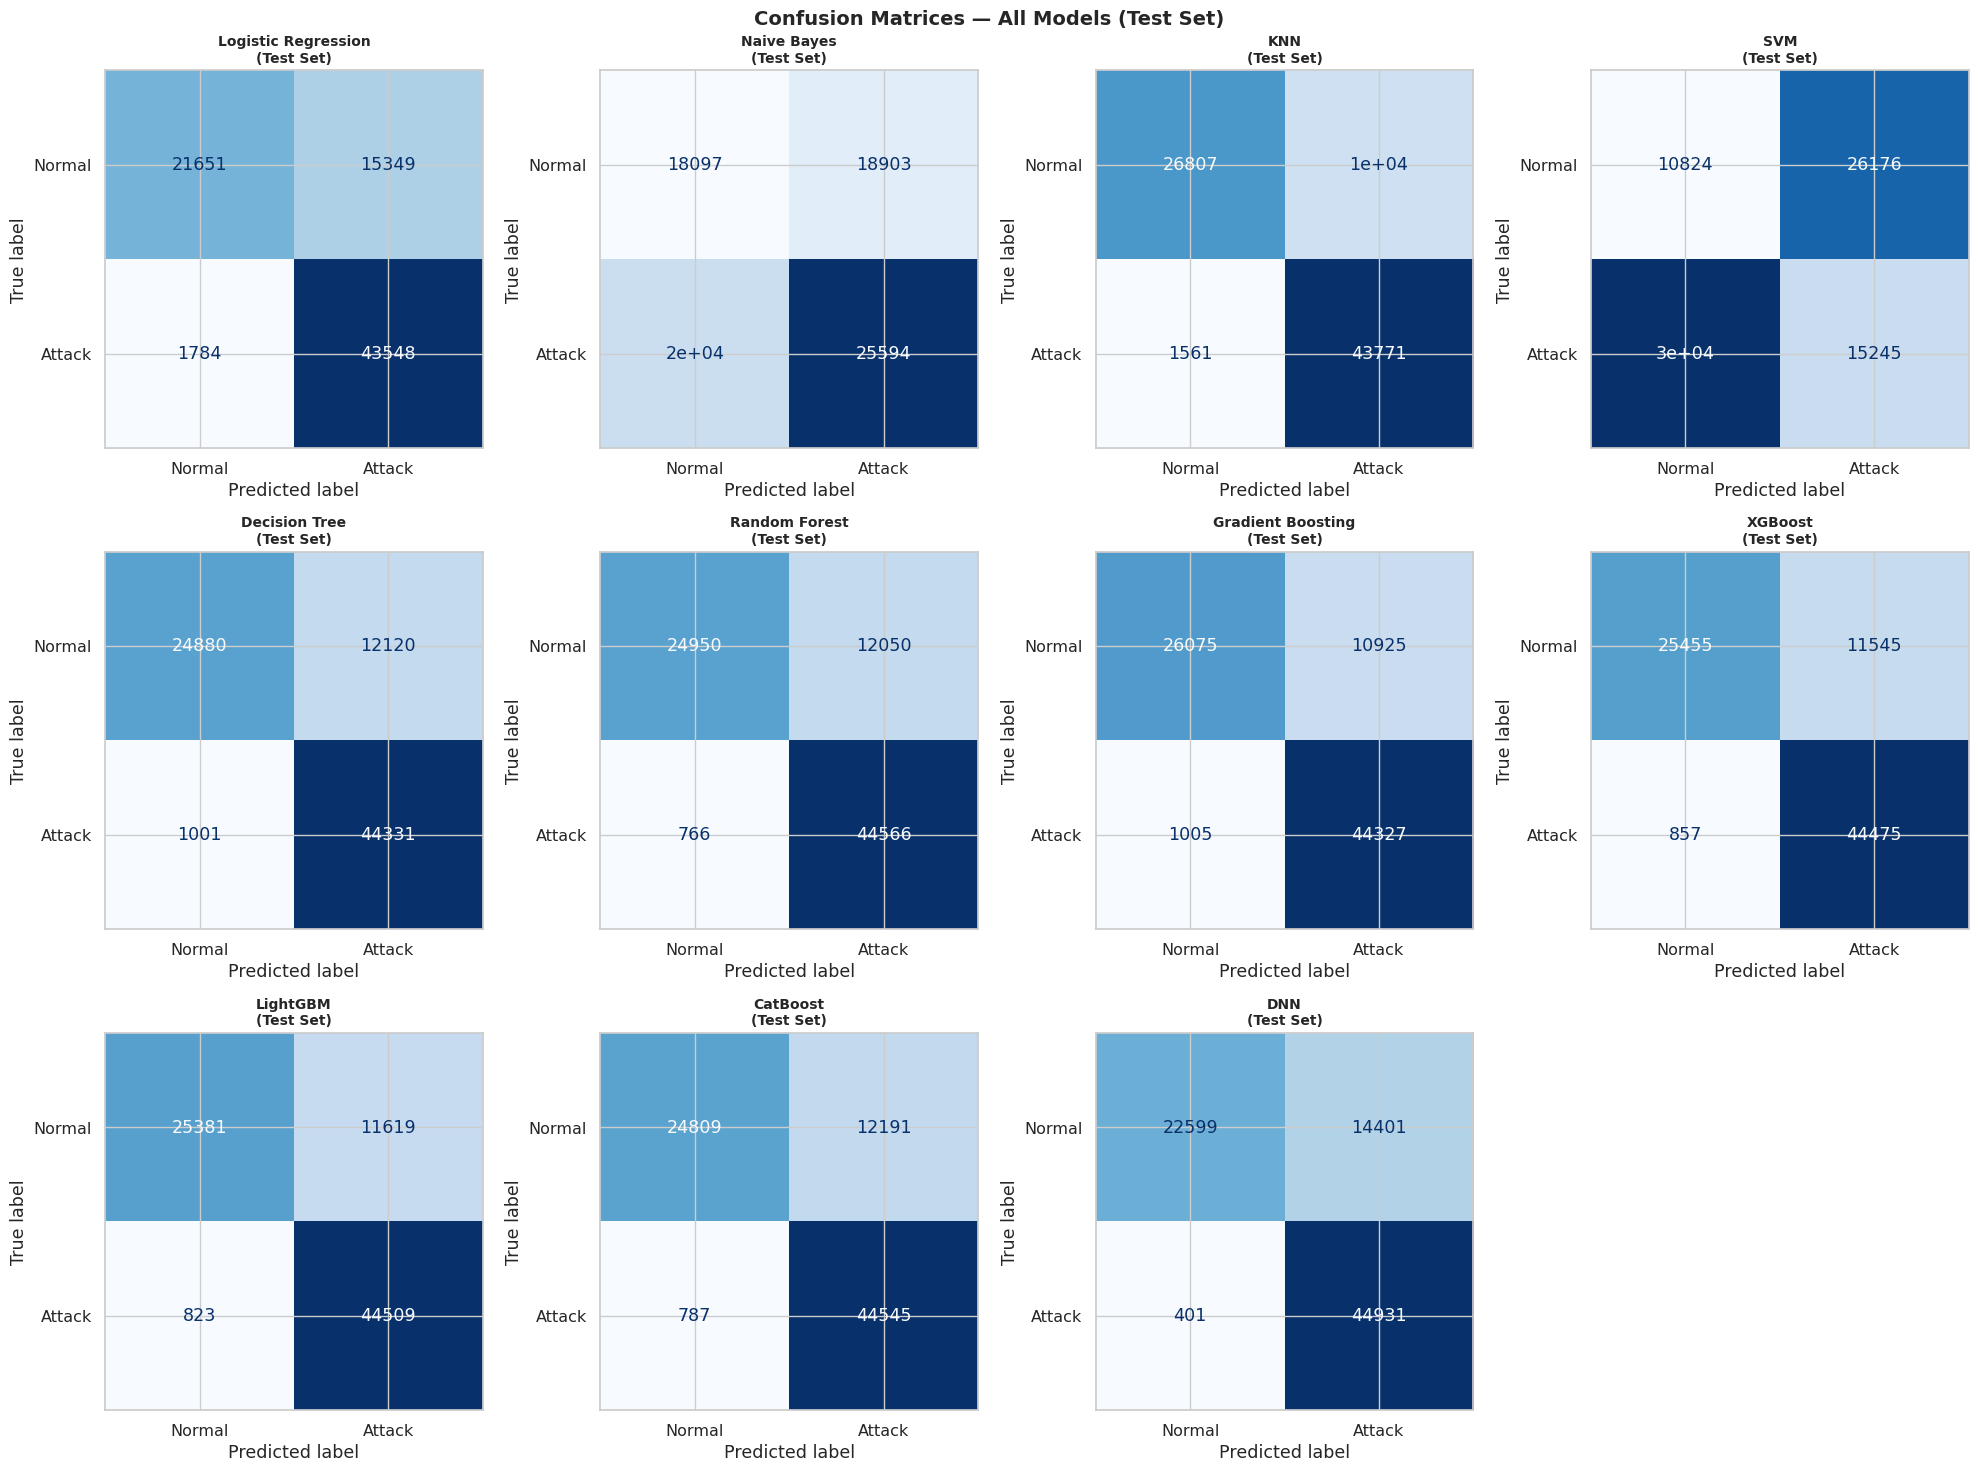

In [23]:
MODEL_NAMES = list(RESULTS.keys())
n_models    = len(MODEL_NAMES)
ncols       = 4
nrows       = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 5))
axes = axes.flatten()

for i, name in enumerate(MODEL_NAMES):
    cm = RESULTS[name]["test"]["cm"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(f"{name}\n(Test Set)", fontweight="bold", fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — All Models (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/confusion_matrices_test.png", dpi=150, bbox_inches="tight")
plt.show()

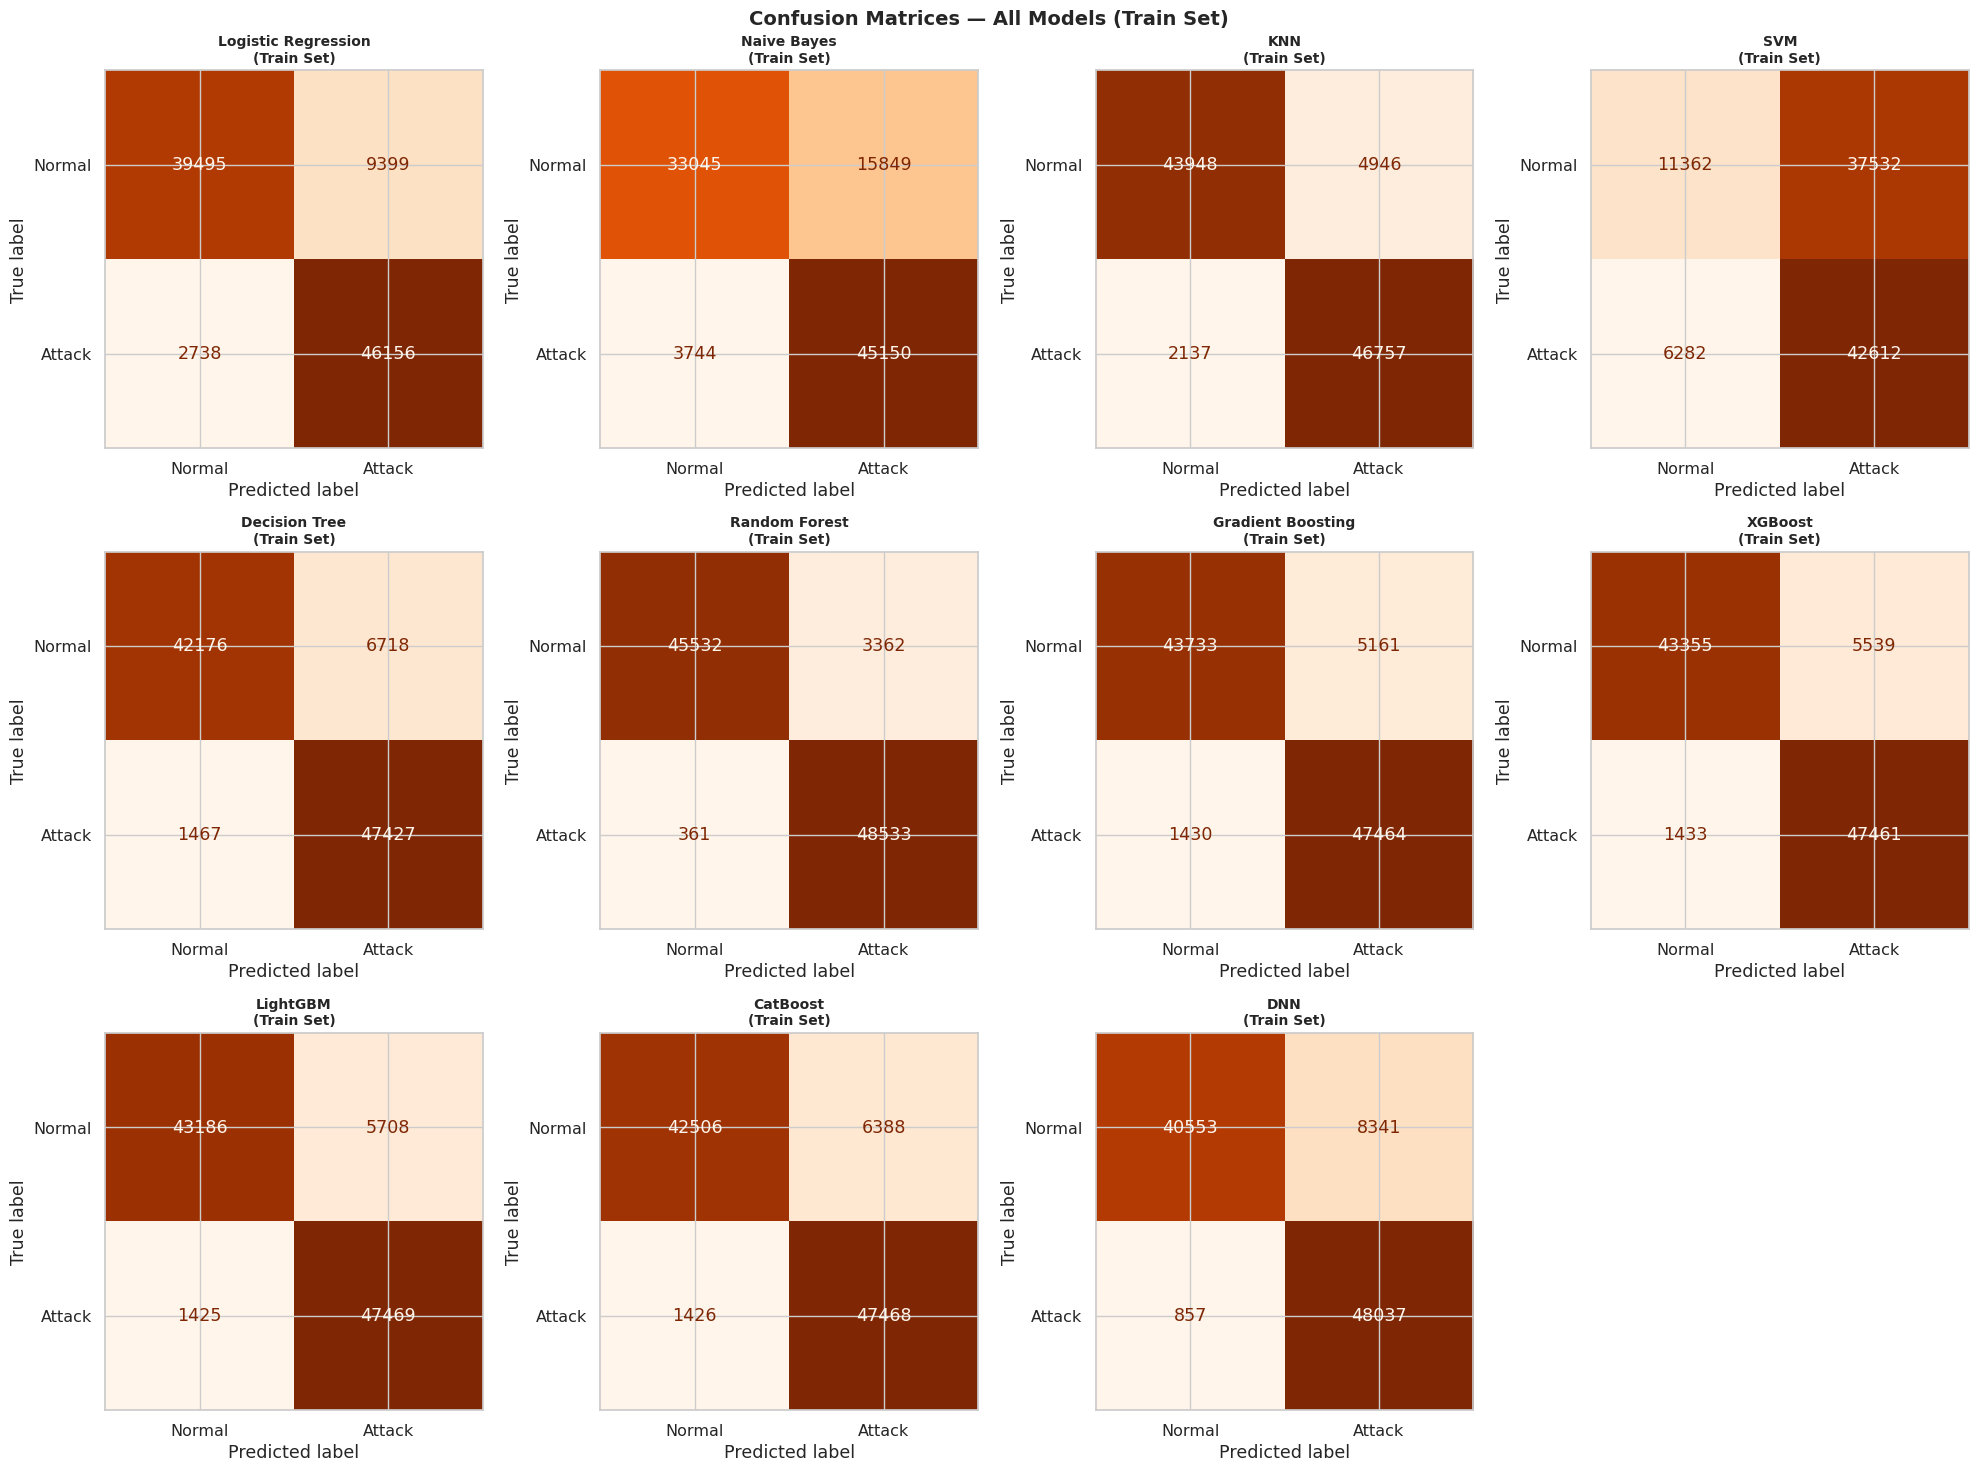

In [24]:
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 5))
axes = axes.flatten()

for i, name in enumerate(MODEL_NAMES):
    cm = RESULTS[name]["train"]["cm"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot(ax=axes[i], colorbar=False, cmap="Oranges")
    axes[i].set_title(f"{name}\n(Train Set)", fontweight="bold", fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — All Models (Train Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/confusion_matrices_train.png", dpi=150, bbox_inches="tight")
plt.show()

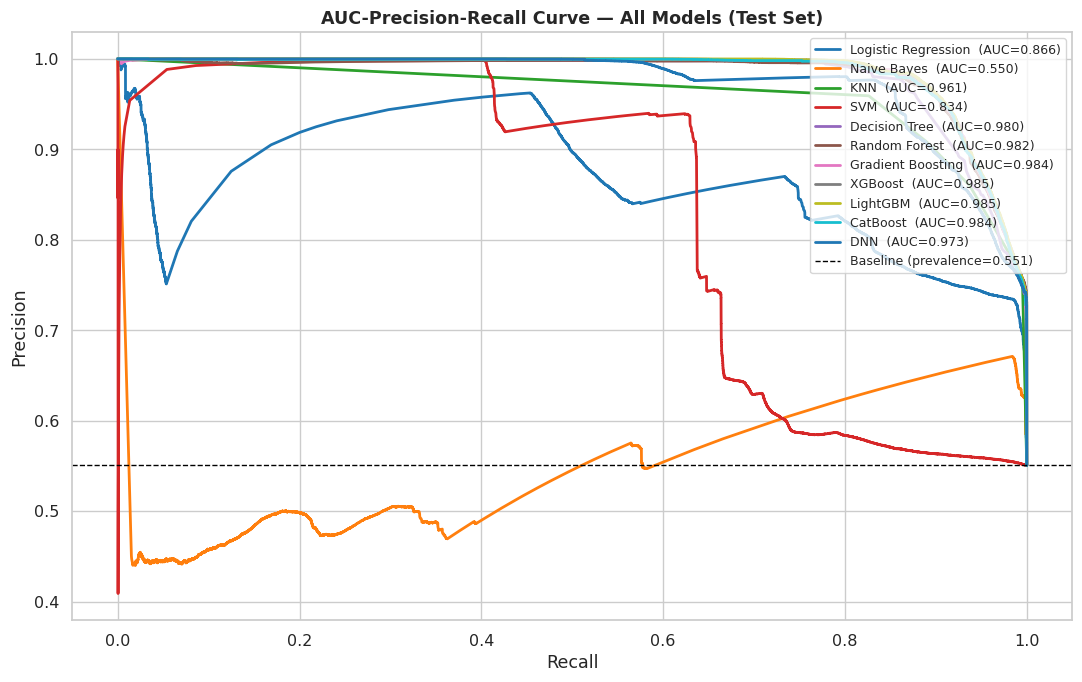

In [25]:

MODEL_TO_OBJ = {
    "Logistic Regression": lr,
    "Naive Bayes":         nb,
    "KNN":                 knn,
    "SVM":                 svm,
    "Decision Tree":       dt,
    "Random Forest":       rf,
    "Gradient Boosting":   gb,
    "XGBoost":             xgb_model,
    "LightGBM":            lgb_model,
    "CatBoost":            cb_model,
}

fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette("tab10", n_colors=n_models)

for idx, name in enumerate(MODEL_NAMES):
    if name == "DNN":
        probs = te_probs
    else:
        probs = MODEL_TO_OBJ[name].predict_proba(X_test)[:, 1]

    p_c, r_c, _ = precision_recall_curve(y_test, probs)
    auc_val      = auc(r_c, p_c)
    ax.plot(r_c, p_c, label=f"{name}  (AUC={auc_val:.3f})",
            color=palette[idx], linewidth=2)

baseline = y_test.mean()
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, label=f"Baseline (prevalence={baseline:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("AUC-Precision-Recall Curve — All Models (Test Set)", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("results/auc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

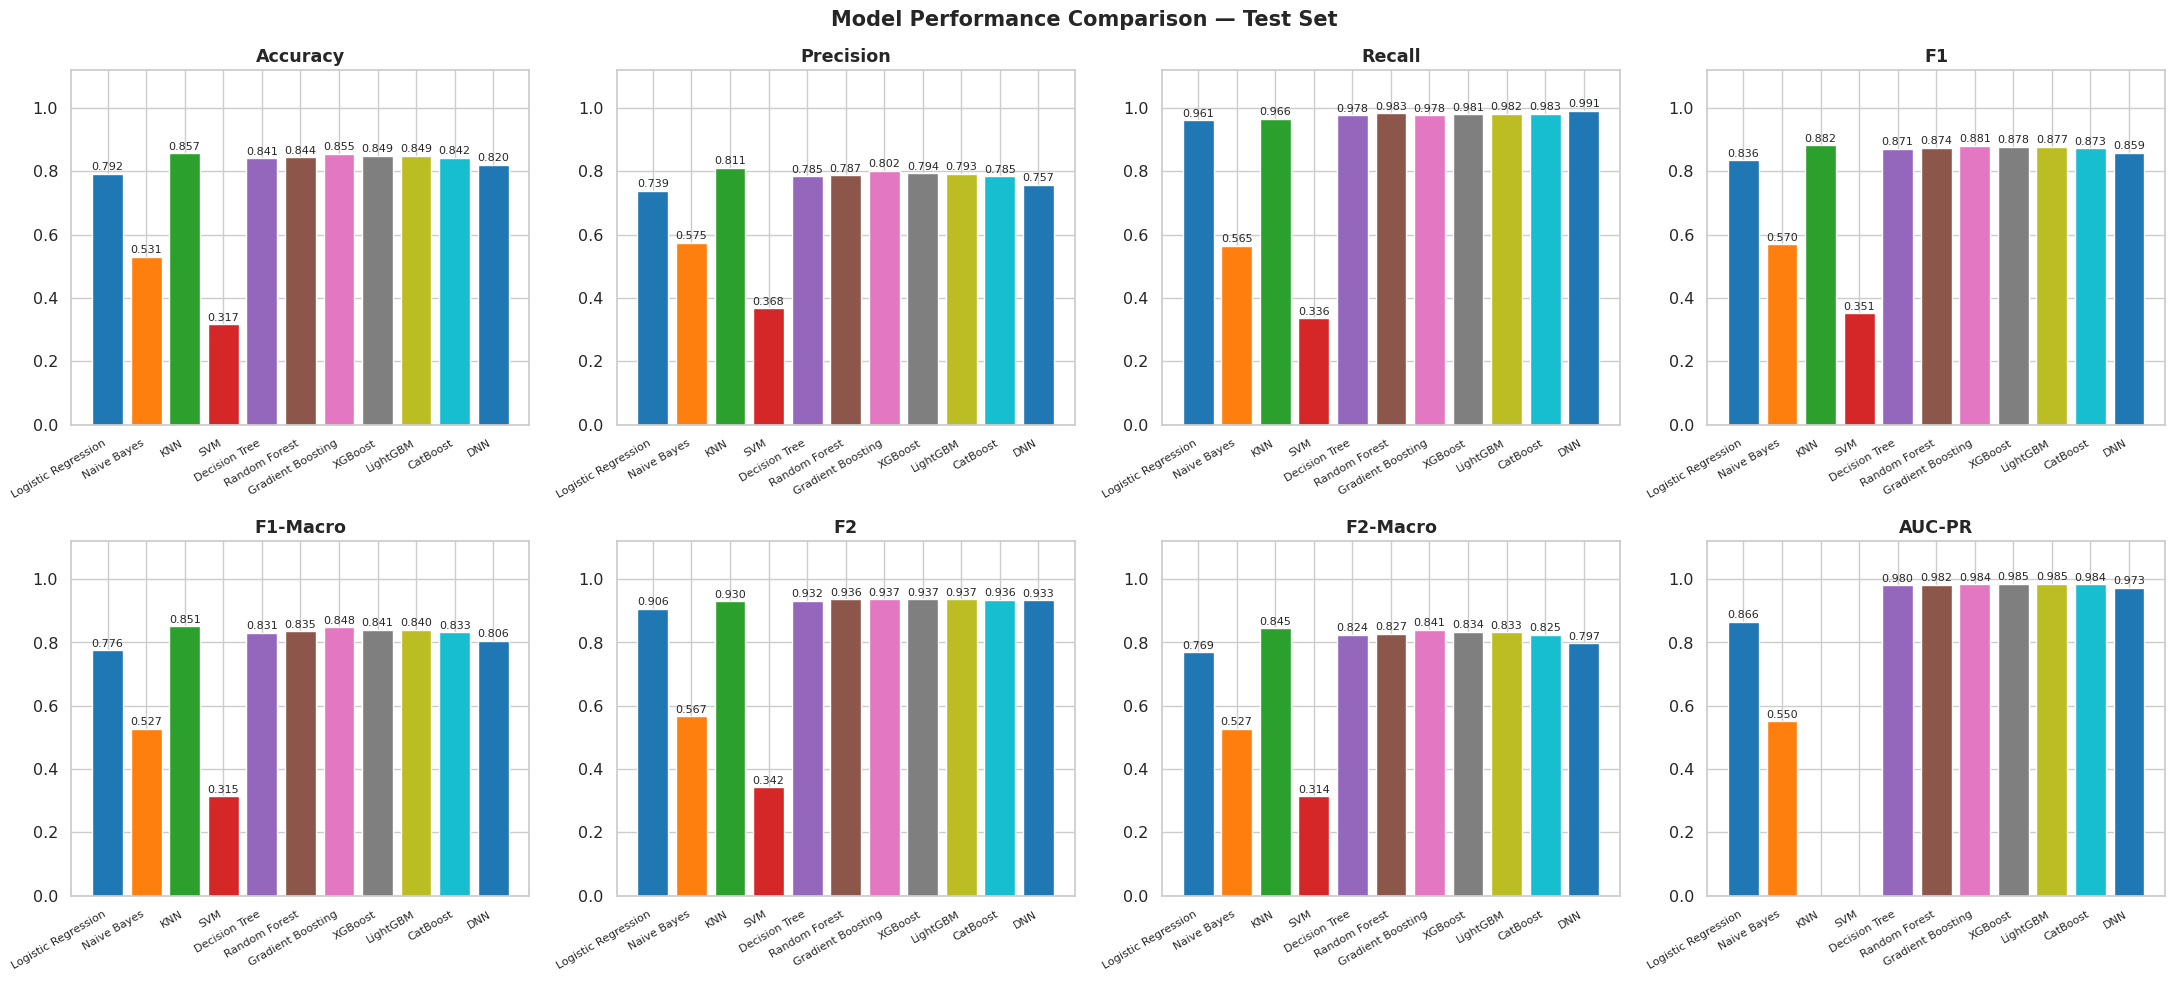

In [26]:

METRIC_KEYS  = ["accuracy", "precision", "recall", "f1", "f1_macro", "f2", "f2_macro", "auc_pr"]
METRIC_LABELS= ["Accuracy", "Precision", "Recall", "F1", "F1-Macro", "F2", "F2-Macro", "AUC-PR"]

test_summary = pd.DataFrame(
    {name: {mk: RESULTS[name]["test"][mk] for mk in METRIC_KEYS} for name in MODEL_NAMES}
).T
test_summary.index.name = "Model"

train_summary = pd.DataFrame(
    {name: {mk: RESULTS[name]["train"][mk] for mk in METRIC_KEYS} for name in MODEL_NAMES}
).T
train_summary.index.name = "Model"

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (mk, ml) in enumerate(zip(METRIC_KEYS, METRIC_LABELS)):
    vals  = test_summary[mk].values
    names = test_summary.index.tolist()
    colors= palette[:len(names)]
    bars  = axes[i].bar(names, vals, color=colors, edgecolor="white")
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.005,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    axes[i].set_title(ml, fontweight="bold")
    axes[i].set_ylim(0, 1.12)
    axes[i].set_xticklabels(names, rotation=30, ha="right", fontsize=8)

plt.suptitle("Model Performance Comparison — Test Set", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("results/metric_comparison_test.png", dpi=150, bbox_inches="tight")
plt.show()

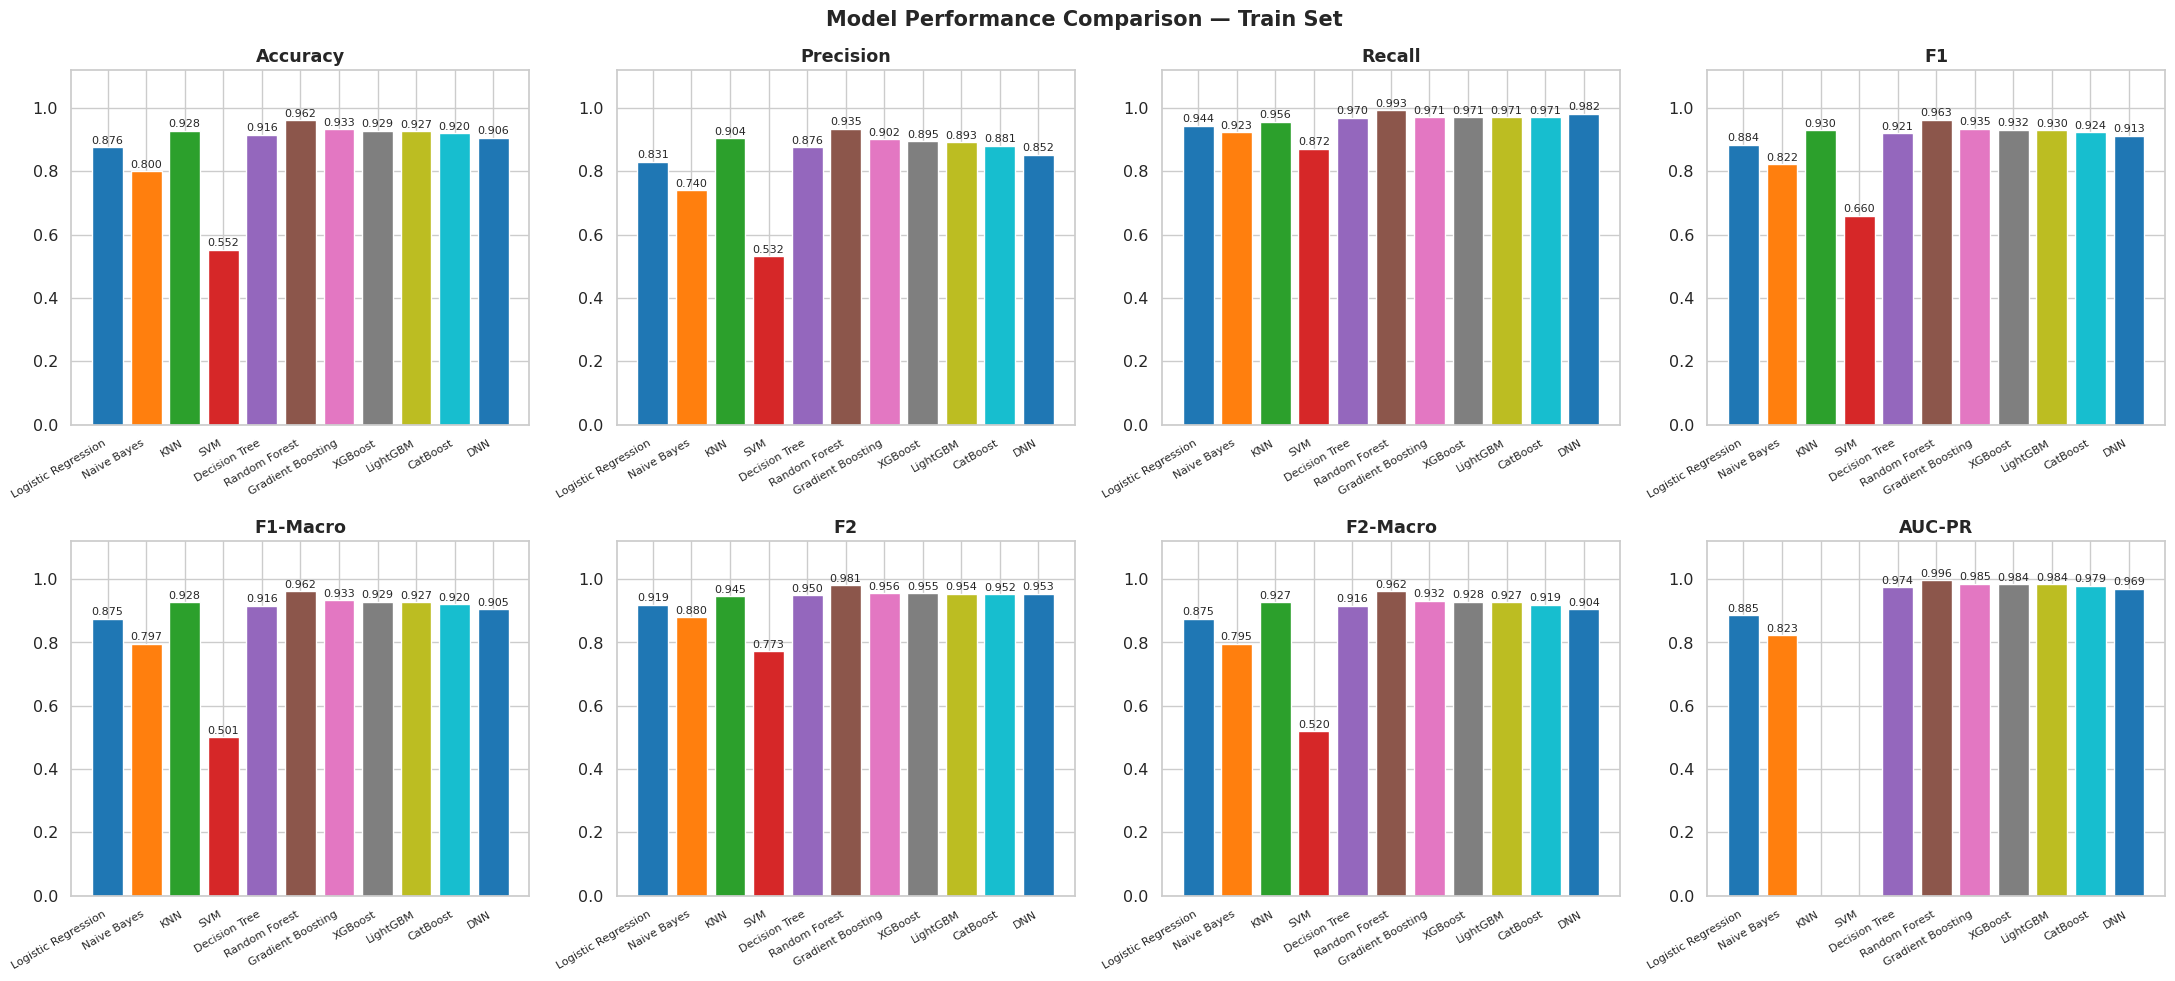

In [27]:

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (mk, ml) in enumerate(zip(METRIC_KEYS, METRIC_LABELS)):
    vals  = train_summary[mk].values
    names = train_summary.index.tolist()
    colors= palette[:len(names)]
    bars  = axes[i].bar(names, vals, color=colors, edgecolor="white")
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.005,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    axes[i].set_title(ml, fontweight="bold")
    axes[i].set_ylim(0, 1.12)
    axes[i].set_xticklabels(names, rotation=30, ha="right", fontsize=8)

plt.suptitle("Model Performance Comparison — Train Set", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("results/metric_comparison_train.png", dpi=150, bbox_inches="tight")
plt.show()

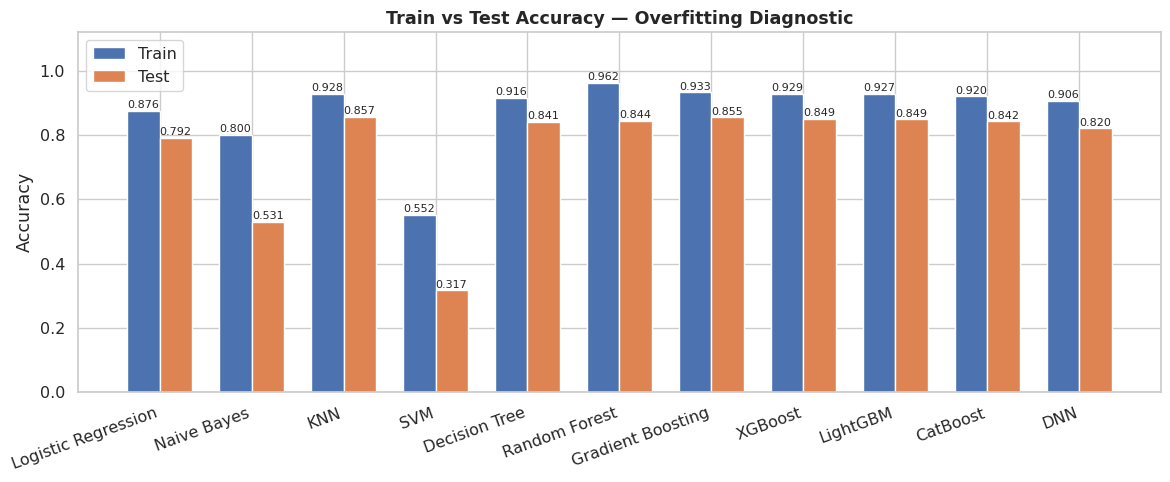

In [28]:

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(MODEL_NAMES))
width   = 0.35

tr_acc = [RESULTS[n]["train"]["accuracy"] for n in MODEL_NAMES]
te_acc = [RESULTS[n]["test"]["accuracy"]  for n in MODEL_NAMES]

bars1 = ax.bar(x - width / 2, tr_acc, width, label="Train", color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + width / 2, te_acc, width, label="Test",  color="#DD8452", edgecolor="white")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, rotation=20, ha="right")
ax.set_ylim(0, 1.12)
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Test Accuracy — Overfitting Diagnostic", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("results/train_test_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

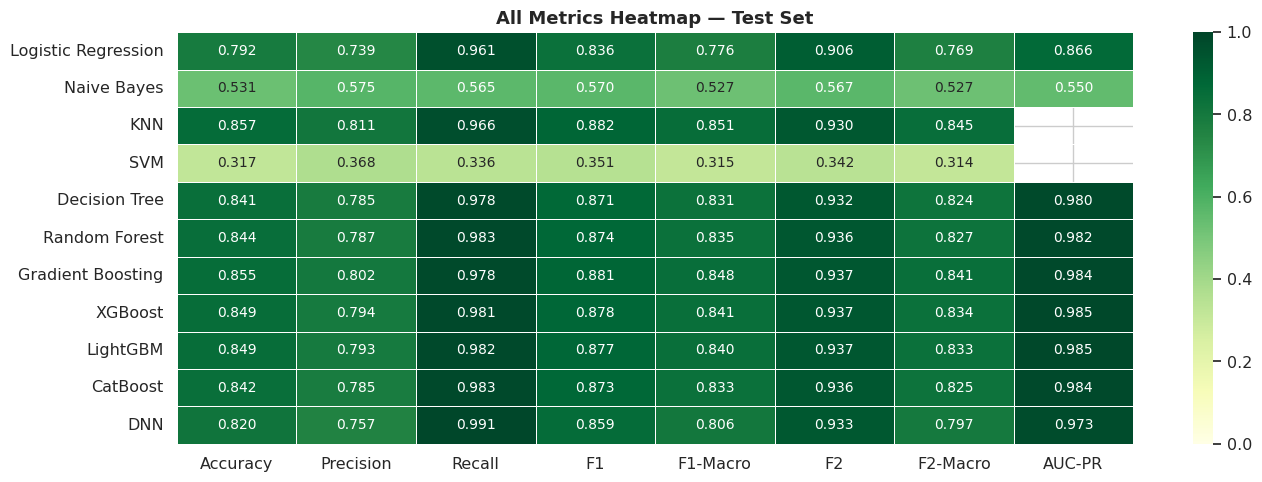

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
hm_data = test_summary[METRIC_KEYS].copy()
hm_data.columns = METRIC_LABELS
sns.heatmap(hm_data, annot=True, fmt=".3f", cmap="YlGn",
            linewidths=0.5, vmin=0, vmax=1, ax=ax,
            annot_kws={"size": 10})
ax.set_title("All Metrics Heatmap — Test Set", fontsize=13, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("results/metrics_heatmap_test.png", dpi=150, bbox_inches="tight")
plt.show()


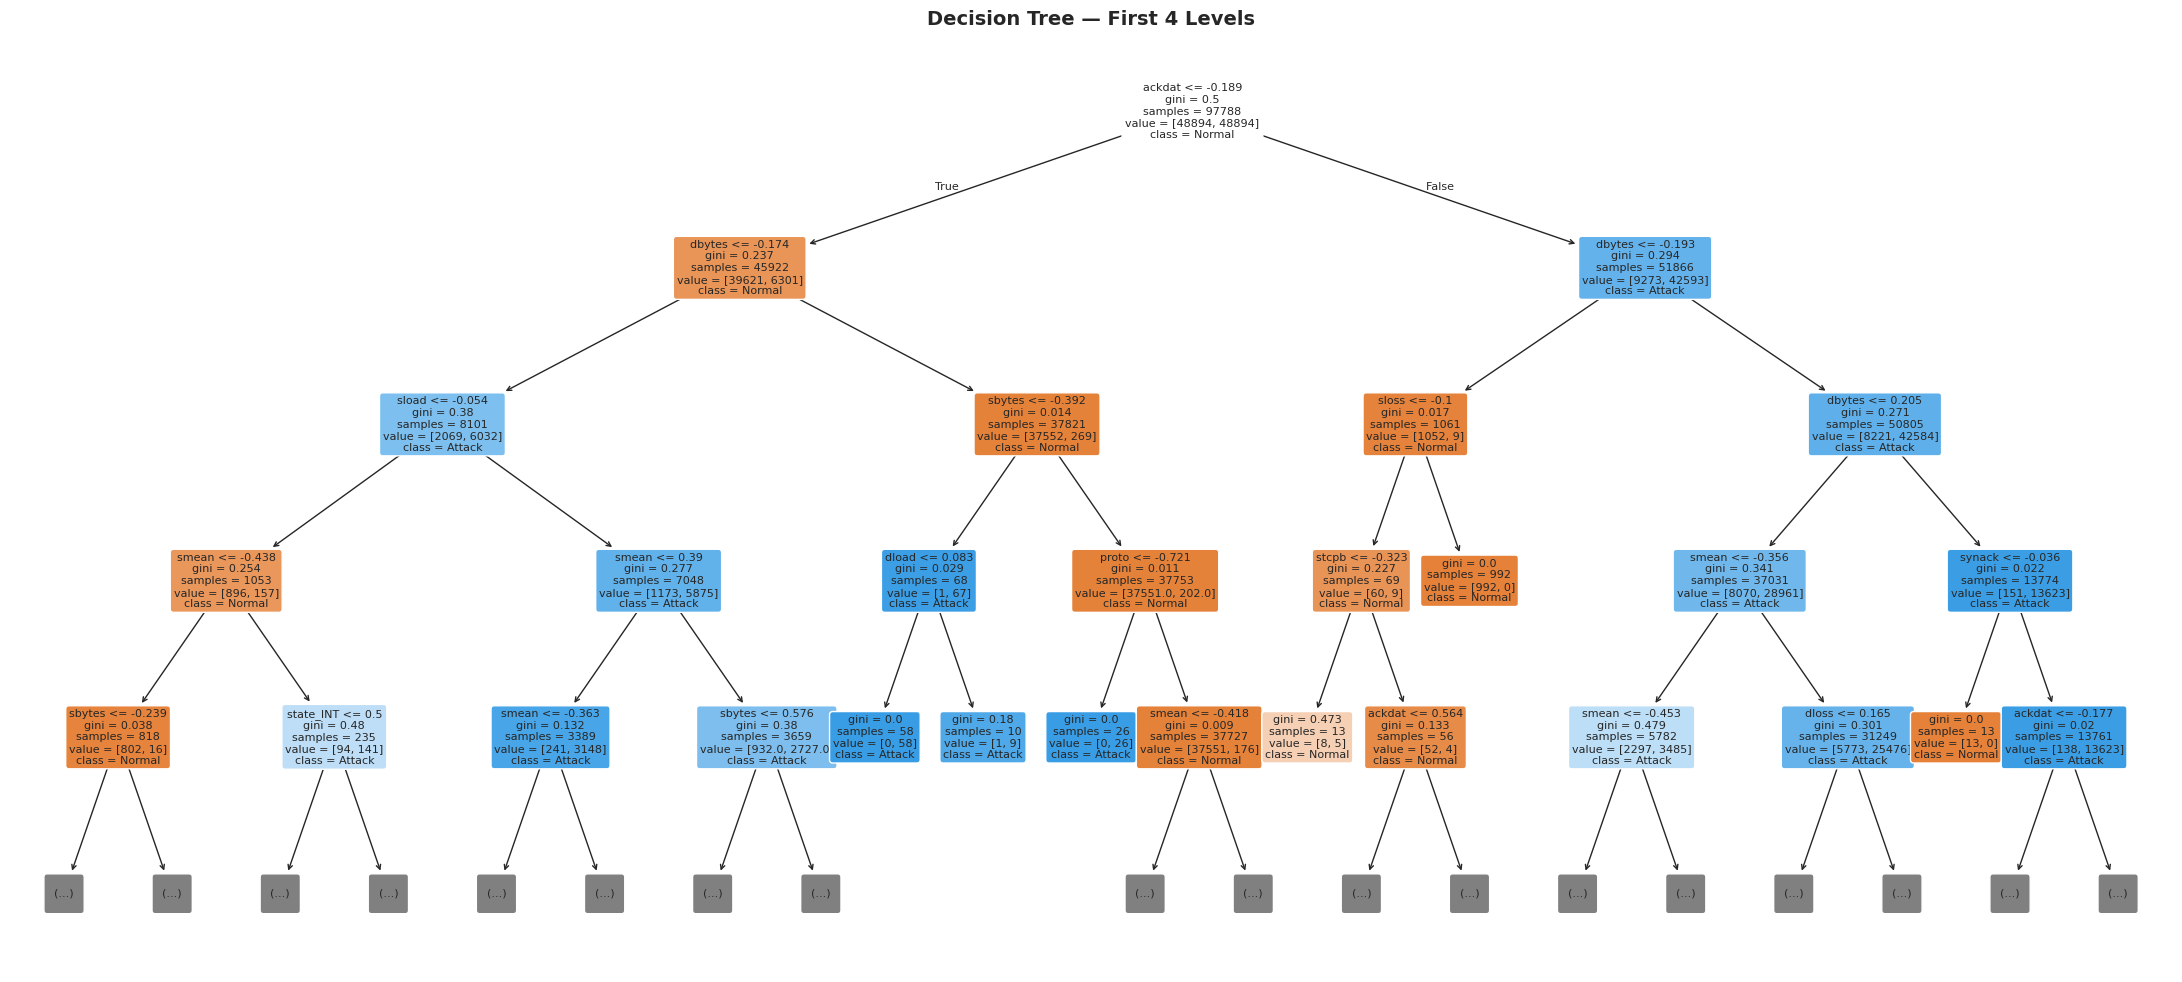

In [30]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    max_depth=4,
    feature_names=FEAT_COLS,
    class_names=["Normal", "Attack"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False,
)
ax.set_title("Decision Tree — First 4 Levels", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/decision_tree_viz.png", dpi=120, bbox_inches="tight")
plt.show()

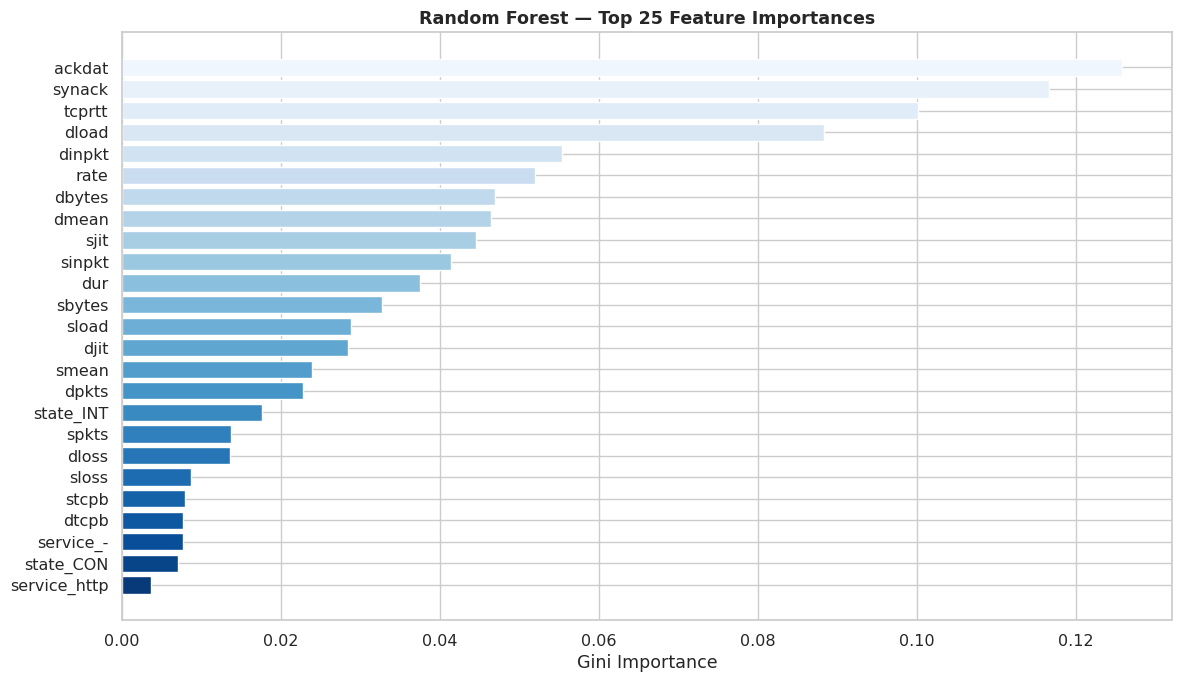

In [31]:
feat_imp = pd.Series(rf.feature_importances_, index=FEAT_COLS).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
        color=sns.color_palette("Blues_r", 25), edgecolor="white")
ax.set_title("Random Forest — Top 25 Feature Importances", fontweight="bold")
ax.set_xlabel("Gini Importance")
plt.tight_layout()
plt.savefig("results/rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


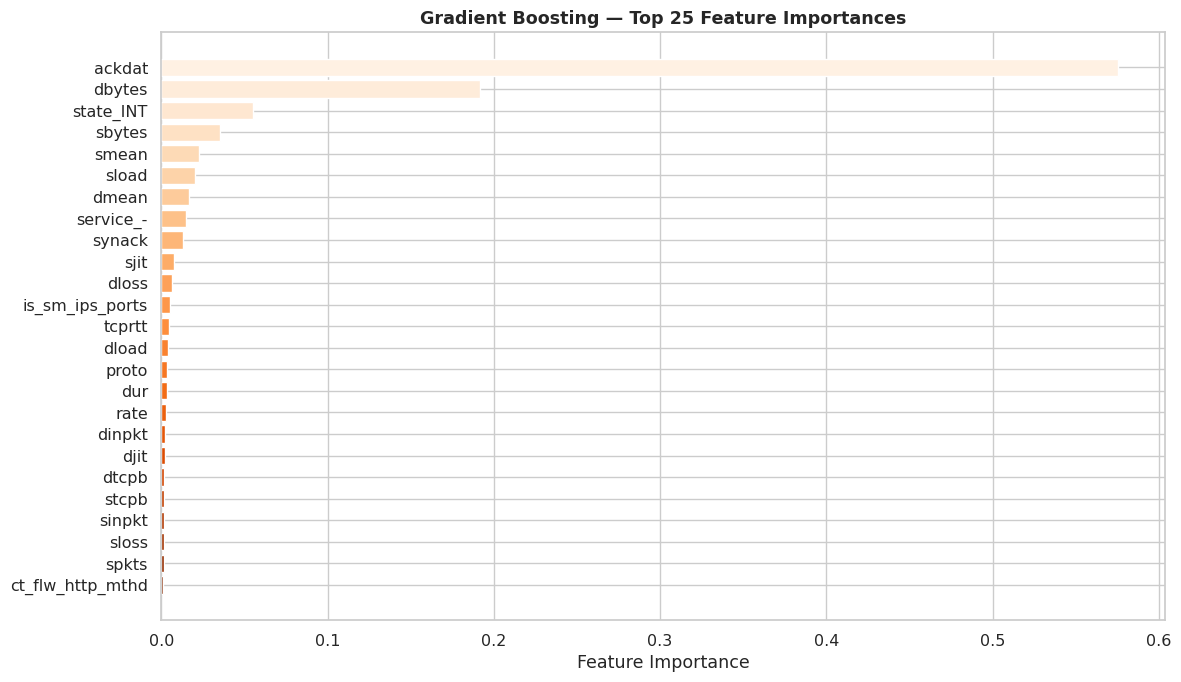

In [32]:
gb_imp = pd.Series(gb.feature_importances_, index=FEAT_COLS).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(gb_imp.index[::-1], gb_imp.values[::-1],
        color=sns.color_palette("Oranges_r", 25), edgecolor="white")
ax.set_title("Gradient Boosting — Top 25 Feature Importances", fontweight="bold")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("results/gb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

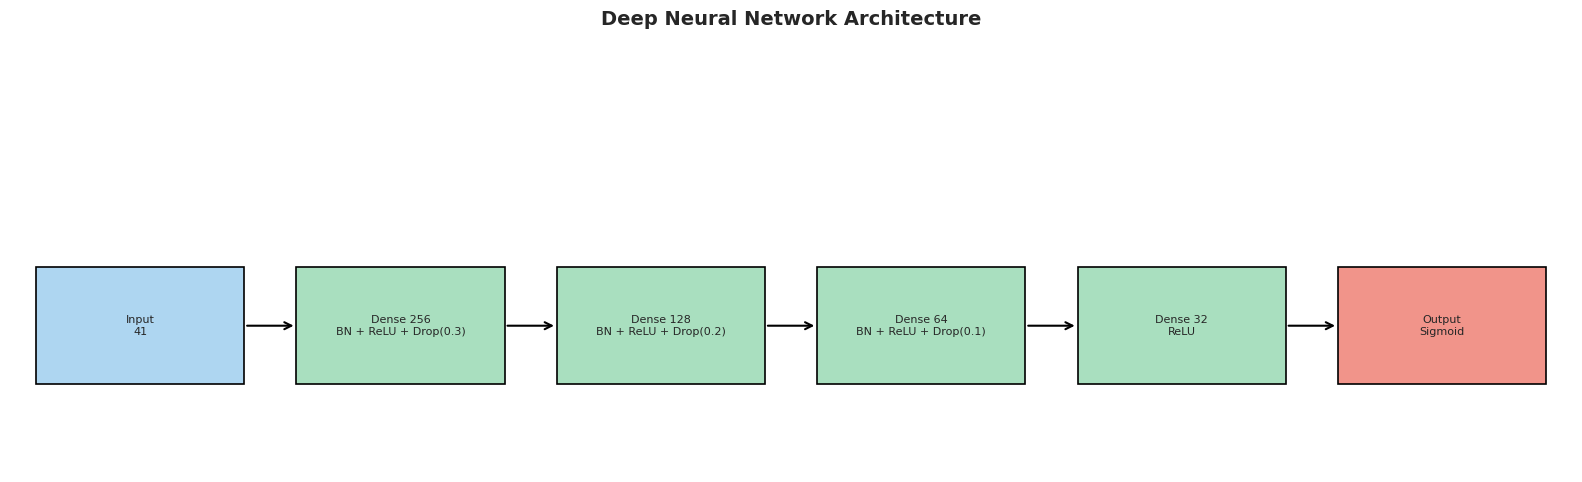

In [33]:

layer_sizes   = [X_train.shape[1], 256, 128, 64, 32, 1]
layer_labels  = [
    f"Input\n{layer_sizes[0]}",
    "Dense 256\nBN + ReLU + Drop(0.3)",
    "Dense 128\nBN + ReLU + Drop(0.2)",
    "Dense 64\nBN + ReLU + Drop(0.1)",
    "Dense 32\nReLU",
    "Output\nSigmoid",
]

fig, ax = plt.subplots(figsize=(16, 5))
ax.set_xlim(-0.5, len(layer_sizes) - 0.5)
ax.set_ylim(-1, 2)
ax.axis("off")
ax.set_title("Deep Neural Network Architecture", fontsize=14, fontweight="bold")

colors = ["#AED6F1", "#A9DFBF", "#A9DFBF", "#A9DFBF", "#A9DFBF", "#F1948A"]

for i, (label, color) in enumerate(zip(layer_labels, colors)):
    rect = plt.Rectangle((i - 0.4, -0.4), 0.8, 0.8, color=color,
                          ec="black", linewidth=1.2, zorder=3)
    ax.add_patch(rect)
    ax.text(i, 0, label, ha="center", va="center", fontsize=8, zorder=4)
    if i < len(layer_sizes) - 1:
        ax.annotate("", xy=(i + 0.4 + 0.2, 0), xytext=(i + 0.4, 0),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))

plt.tight_layout()
plt.savefig("results/dnn_architecture.png", dpi=150, bbox_inches="tight")
plt.show()

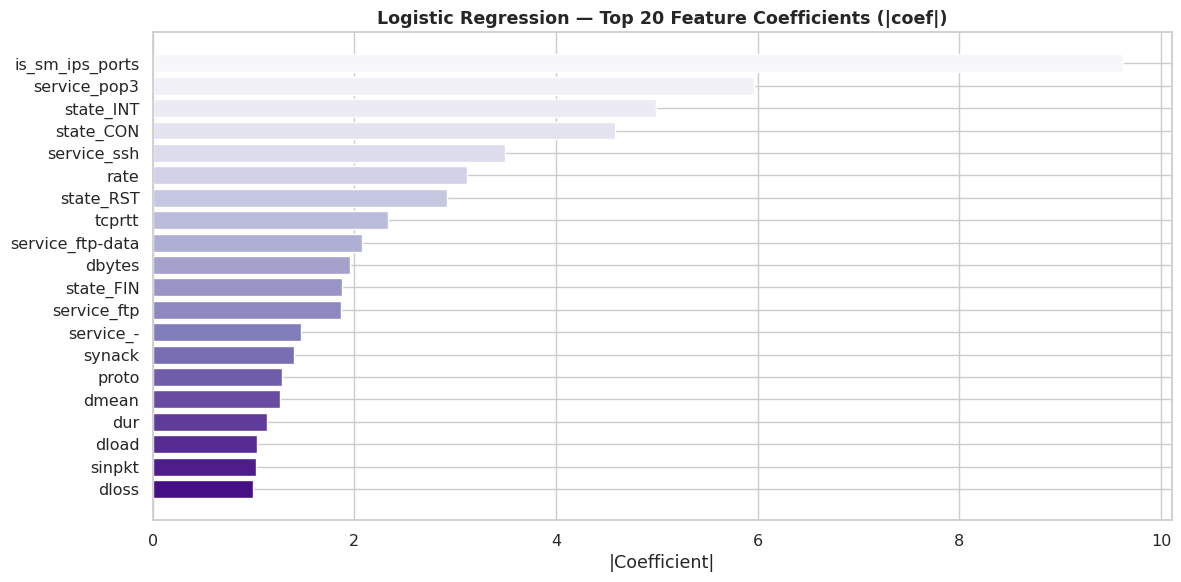

In [34]:
lr_coef = pd.Series(lr.coef_[0], index=FEAT_COLS).abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(lr_coef.index[::-1], lr_coef.values[::-1],
        color=sns.color_palette("Purples_r", 20), edgecolor="white")
ax.set_title("Logistic Regression — Top 20 Feature Coefficients (|coef|)", fontweight="bold")
ax.set_xlabel("|Coefficient|")
plt.tight_layout()
plt.savefig("results/lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:

def print_metrics():
    lines = []
    sep   = "=" * 70

    lines.append(sep)
    lines.append("  NIDS CLASSIFICATION REPORT — ALL MODELS")
    lines.append(sep)

    header_fmt  = f"  {'Metric':<20} {'Train':>10} {'Test':>10} {'Gap':>10}"
    divider_fmt = f"  {'-'*50}"

    for name in MODEL_NAMES:
        m_tr = RESULTS[name]["train"]
        m_te = RESULTS[name]["test"]

        lines.append(f"\n  MODEL : {name}")
        lines.append(divider_fmt)
        lines.append(header_fmt)
        lines.append(divider_fmt)

        for mk in ["accuracy","precision","recall","f1","f1_macro","f2","f2_macro","auc_pr"]:
            tr_val = m_tr[mk]
            te_val = m_te[mk]
            gap    = te_val - tr_val
            lines.append(f"  {mk:<20} {tr_val:>10.4f} {te_val:>10.4f} {gap:>+10.4f}")

        cm_te = m_te["cm"]
        tn, fp, fn, tp = cm_te.ravel()
        lines.append(f"\n  Confusion Matrix (Test):")
        lines.append(f"    TN={tn:>6,}  FP={fp:>6,}")
        lines.append(f"    FN={fn:>6,}  TP={tp:>6,}")

    lines.append(f"\n{sep}")
    lines.append("  TEST SET RANKING BY F2-MACRO")
    lines.append(sep)
    ranked = sorted(MODEL_NAMES, key=lambda n: RESULTS[n]["test"]["f2_macro"], reverse=True)
    for rank, name in enumerate(ranked, 1):
        f2m = RESULTS[name]["test"]["f2_macro"]
        acc = RESULTS[name]["test"]["accuracy"]
        rec = RESULTS[name]["test"]["recall"]
        lines.append(f"  {rank}. {name:<24}  F2-Macro={f2m:.4f}  Recall={rec:.4f}  Accuracy={acc:.4f}")

    lines.append(f"\n{sep}")
    lines.append("  BEST MODEL PER METRIC (TEST SET)")
    lines.append(sep)
    for mk in ["accuracy","precision","recall","f1","f1_macro","f2","f2_macro","auc_pr"]:
        best_name = max(MODEL_NAMES, key=lambda n: RESULTS[n]["test"][mk])
        best_val  = RESULTS[best_name]["test"][mk]
        lines.append(f"  {mk:<20} best: {best_name:<24} ({best_val:.4f})")

    lines.append(f"\n{sep}")
    lines.append("  DNN TRAINING HISTORY (FINAL EPOCH)")
    lines.append(sep)
    lines.append(f"  Train Loss : {history['train_loss'][-1]:.4f}")
    lines.append(f"  Train Acc  : {history['train_acc'][-1]:.4f}")
    lines.append(f"  Test  Loss : {history['test_loss'][-1]:.4f}")
    lines.append(f"  Test  Acc  : {history['test_acc'][-1]:.4f}")
    lines.append(sep)

    full_text = "\n".join(lines)
    print(full_text)

    with open("results/metrics_report.txt", "w") as f:
        f.write(full_text)

    print(f"\nReport saved to results/metrics_report.txt")


print_metrics()

  NIDS CLASSIFICATION REPORT — ALL MODELS

  MODEL : Logistic Regression
  --------------------------------------------------
  Metric                    Train       Test        Gap
  --------------------------------------------------
  accuracy                 0.8759     0.7919    -0.0840
  precision                0.8308     0.7394    -0.0914
  recall                   0.9440     0.9606    +0.0166
  f1                       0.8838     0.8356    -0.0482
  f1_macro                 0.8753     0.7761    -0.0992
  f2                       0.9190     0.9064    -0.0126
  f2_macro                 0.8747     0.7689    -0.1057
  auc_pr                   0.8853     0.8659    -0.0194

  Confusion Matrix (Test):
    TN=21,651  FP=15,349
    FN= 1,784  TP=43,548

  MODEL : Naive Bayes
  --------------------------------------------------
  Metric                    Train       Test        Gap
  --------------------------------------------------
  accuracy                 0.7996     0.5307    -0.269